1.	Load the dataset into a pandas DataFrame and inspect its structure.

In [ ]:
import pandas as pd
df = pd.read_csv("Sales_April_2019.csv")

In [ ]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [ ]:
df.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18383 entries, 0 to 18382
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order ID          18324 non-null  object
 1   Product           18324 non-null  object
 2   Quantity Ordered  18324 non-null  object
 3   Price Each        18324 non-null  object
 4   Order Date        18324 non-null  object
 5   Purchase Address  18324 non-null  object
dtypes: object(6)
memory usage: 861.8+ KB


2.	Extract 'City' and 'State' information from the Purchase Address column and add these as separate columns.

In [ ]:
df['City'] = df['Purchase Address'].str.split(',').str[1].str.strip()
df['State'] = df['Purchase Address'].str.split(',').str[2].str.strip().str.split(' ').str[0]

In [ ]:
df.head ()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,City,State
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",Dallas,TX
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",Boston,MA
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",Los Angeles,CA
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",Los Angeles,CA


3.	Calculate total sales (Quantity Ordered * Price Each) and create a new column Total Sales.

In [ ]:
#Convert columns to numeric
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'], errors='coerce')
df['Price Each'] = pd.to_numeric(df['Price Each'], errors='coerce')

In [ ]:
#Creating total sales column
df['Total Sales'] = df['Quantity Ordered'] * df['Price Each']
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,City,State,Total Sales
0,176558,USB-C Charging Cable,2.0,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",Dallas,TX,23.90
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1.0,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",Boston,MA,99.99
3,176560,Google Phone,1.0,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",Los Angeles,CA,600.00
4,176560,Wired Headphones,1.0,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",Los Angeles,CA,11.99


4.	Find out the top 5 products sold by total sales value

In [ ]:
top_products = df.groupby('Product')['Total Sales'].sum()
top_products = top_products.sort_values(ascending=False)
top_5_products = top_products.head(5)
print(top_5_products)

Product
Macbook Pro Laptop        773500.00
iPhone                    486500.00
ThinkPad Laptop           391996.08
Google Phone              348600.00
34in Ultrawide Monitor    248133.47
Name: Total Sales, dtype: float64


5.	Identify the city with the highest sales in April 2019

In [ ]:
city_sales = df.groupby('City')['Total Sales'].sum()
city_sales = city_sales.sort_values(ascending=False)
top_city = city_sales.head(1)
print(top_city)

City
San Francisco    817074.77
Name: Total Sales, dtype: float64


6.	Aggregate and plot total sales by date to identify sales trends throughout the month

In [ ]:
df['Order Date'].dtype

dtype('O')

In [ ]:
#setting up in order date format
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Order Date'] = pd.to_datetime(df['Order Date'])

/tmp/ipython-input-12678/2691842628.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')


In [ ]:
df['Date'] = df['Order Date'].dt.date #extracting date only

daily_sales = df.groupby('Date')['Total Sales'].sum() #aggregating total sales
print (daily_sales)

Date
2019-04-01    107527.34
2019-04-02    104496.71
2019-04-03    113611.75
2019-04-04    116214.99
2019-04-05    114012.88
2019-04-06    109928.87
2019-04-07    103941.95
2019-04-08     94885.95
2019-04-09    112286.25
2019-04-10    120373.48
2019-04-11    113048.28
2019-04-12    109263.75
2019-04-13    106087.76
2019-04-14    105730.53
2019-04-15    110242.20
2019-04-16    120860.86
2019-04-17    126445.19
2019-04-18    129520.55
2019-04-19    101059.56
2019-04-20     96773.82
2019-04-21    120653.93
2019-04-22     91174.98
2019-04-23    111792.56
2019-04-24    136177.32
2019-04-25    124453.24
2019-04-26    115389.09
2019-04-27    122127.73
2019-04-28    107756.66
2019-04-29    122115.62
2019-04-30    117546.02
2019-05-01     10559.29
Name: Total Sales, dtype: float64


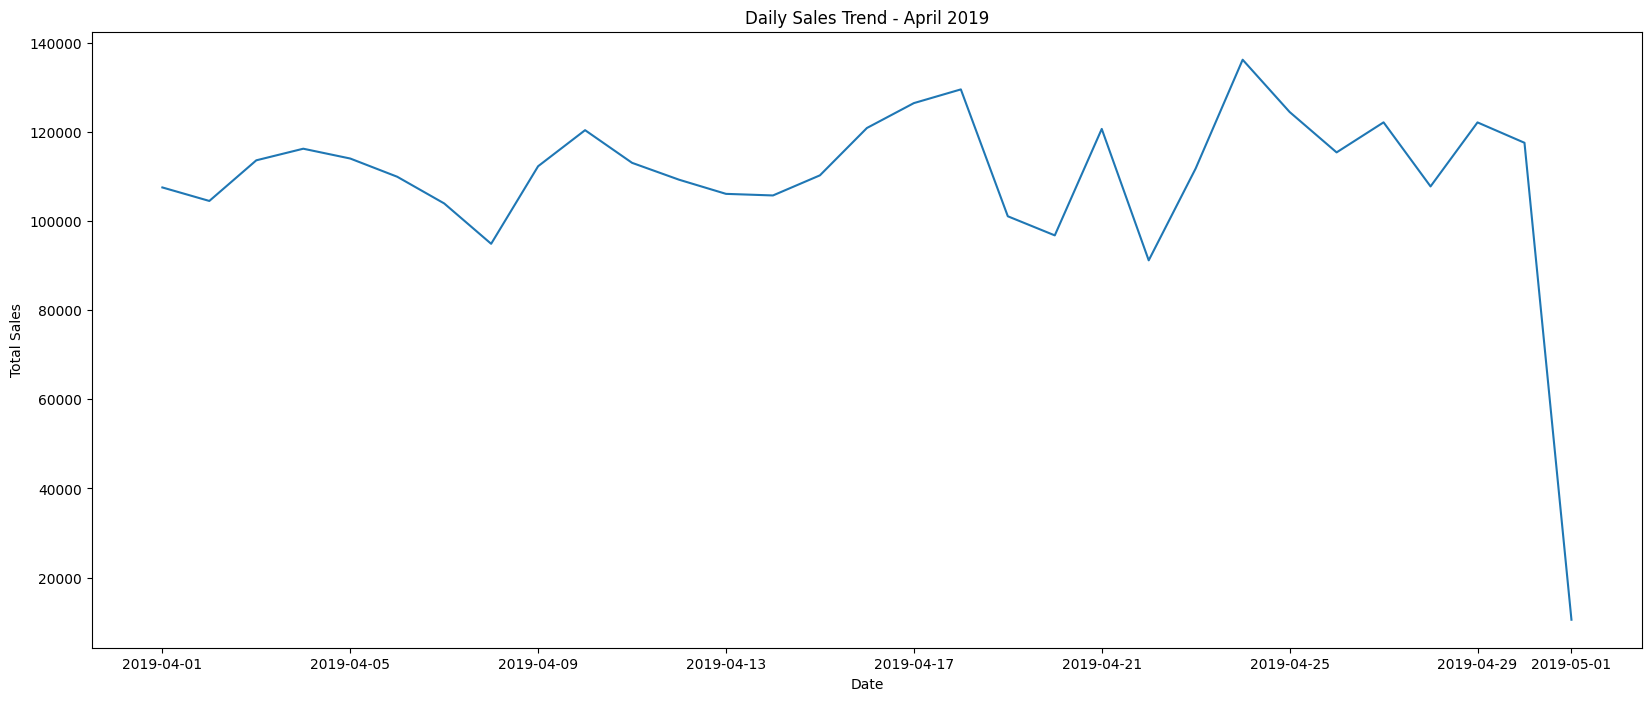

In [ ]:
#plotting sales trend
import matplotlib.pyplot as plt
plt.figure(figsize=(20,8))
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Daily Sales Trend - April 2019")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()